### Nome: Wesley Vitorino Teixeira
### Matrícula: 2260602

### Pacotes importados

In [ ]:
using Printf
using LinearAlgebra
using Plots

## Chapter 8: Quasi-Newton methods

### Algorithm 8.1: Finite difference Newton's method: one variable

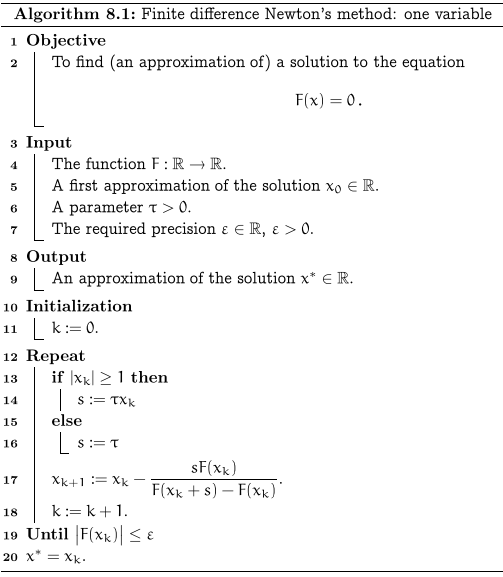

Example: $F(x)=x^2-2$. Run the example with $x_0=2$ and $\tau=10^{-7}$


▶  Finite Difference Newton — Algorithm 8.1
   F(x) = x² − 2 = 0
   x₀ = 2,   τ = 1e-7,   ε = 1e-15

──────────────────────────────────────────────────────────────────────────────────────
  k      x_k                     F(x_k)                  s_k                 F'_approx     
──────────────────────────────────────────────────────────────────────────────────────
  0      2.000000000000000       2.000000000000000       2.000000e-07        4.0000002022  
  1      1.500000025271950       0.250000075815851       1.500000e-07        3.0000002006  
  2      1.416666672239940       0.006944460235386       1.416667e-07        2.8333334877  
  3      1.414215686408005       0.000006007682464       1.414216e-07        2.8284315138  
  4      1.414213562374796       0.000000000004811       1.414214e-07        2.8284272677  
  5      1.414213562373095       0.000000000000000       1.414214e-07        2.8284272646  
────────────────────────────────────────────────────────────────────────────────

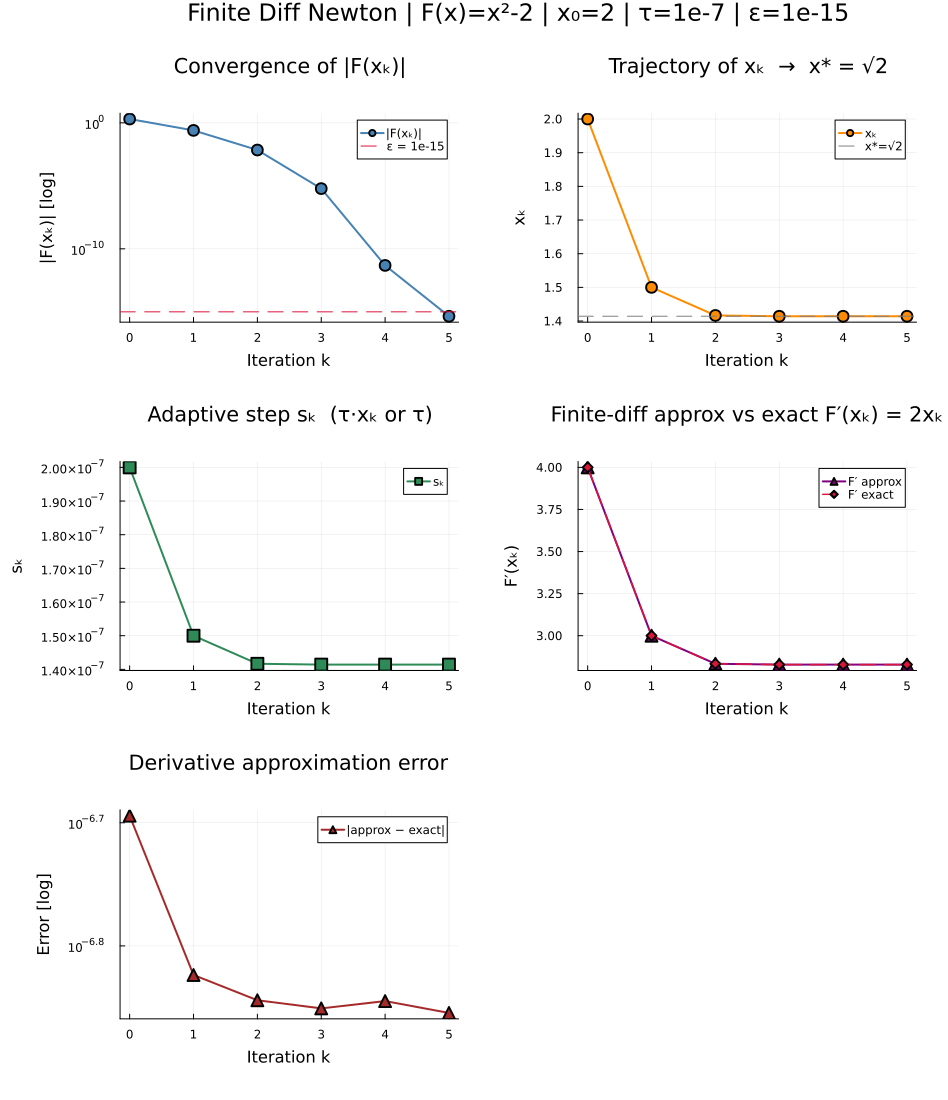

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm - Finite Difference Newton's Method: one variable
#
# Key idea: replaces the exact derivative F′(xₖ) with the finite difference
#
#         F(xₖ + s) − F(xₖ)
#   F′ ≈  ─────────────────
#                 s
#
# where the step s adapts to the magnitude of xₖ:
#   |xₖ| ≥ 1  →  s = τ·xₖ    (relative step)
#   |xₖ| < 1  →  s = τ        (absolute step)
#
# Update rule (line 17):
#   xₖ₊₁ := xₖ − s·F(xₖ) / [F(xₖ+s) − F(xₖ)]
#
# Input:  F, x₀, τ, ε
# Output: x* ≈ solution of F(x) = 0
# ─────────────────────────────────────────────────────────────────────────────

function newton_findiff(F, x0::Float64;
                        τ::Float64  = 1e-7,
                        ε::Float64  = 1e-15,
                        maxiter::Int = 1000)

    println("─"^86)
    @printf("  %-5s  %-22s  %-22s  %-18s  %-14s\n",
            "k", "x_k", "F(x_k)", "s_k", "F'_approx")
    println("─"^86)

    k  = 0                              # line 11 – Initialization
    xk = x0

    history = NamedTuple[]

    function step_size(xk)             # lines 13–16
        abs(xk) ≥ 1 ? τ * xk : τ
    end

    function record_and_print(k, xk, s)
        Fxk    = F(xk)
        Fxks   = F(xk + s)
        dapprox = (Fxks - Fxk) / s
        push!(history, (k=k, x=xk, Fx=Fxk, s=s, dapprox=dapprox))
        @printf("  %-5d  %-22.15f  %-22.15f  %-18.6e  %-14.10f\n",
                k, xk, Fxk, s, dapprox)
    end

    # initial row
    record_and_print(k, xk, step_size(xk))

    status = :running
    while true                          # line 12 – Repeat

        s    = step_size(xk)            # lines 13–16
        Fxk  = F(xk)
        Fxks = F(xk + s)
        denom = Fxks - Fxk

        if abs(denom) < 1e-30
            println("  ⚠  F(xₖ+s) − F(xₖ) ≈ 0 at k=$k — stopping.")
            status = :singular; break
        end

        xk1 = xk - s * Fxk / denom    # line 17 – finite difference Newton step
        k  += 1                         # line 18 – k := k + 1
        xk  = xk1

        if !isfinite(xk)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        record_and_print(k, xk, step_size(xk))

        if abs(F(xk)) ≤ ε              # line 19 – Until |F(xₖ)| ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println("─"^86)
    sym = status == :converged ? "✔  Converged" : "✘  Did not converge"
    @printf("\n  %s:  x* = %.15f\n", sym, xk)
    @printf("  |F(x*)| = %.6e   (iterations: %d,  status: %s)\n\n",
            abs(F(xk)), k, status)

    return xk, history                  # line 20 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example:  F(x) = x² − 2 = 0   →   x* = √2
#           x₀ = 2,   τ = 1e-7,   ε = 1e-15
# ─────────────────────────────────────────────────────────────────────────────

F_ex  = x -> x^2 - 2.0
dF_ex = x -> 2.0 * x     # exact derivative — used only for comparison

println("\n▶  Finite Difference Newton — Algorithm 8.1")
println("   F(x) = x² − 2 = 0")
println("   x₀ = 2,   τ = 1e-7,   ε = 1e-15\n")

xstar, hist = newton_findiff(F_ex, 2.0; τ = 1e-7, ε = 1e-15)

@printf("  √2 (reference) = %.15f\n", sqrt(2.0))
@printf("  error          = %.6e\n\n", abs(xstar - sqrt(2.0)))

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks      = [h.k        for h in hist]
xtk     = 0:maximum(ks)
xks     = [h.x        for h in hist]
fks     = [abs(h.Fx)  for h in hist]
sks     = [abs(h.s)   for h in hist]
dapprox = [h.dapprox  for h in hist]
dexact  = [dF_ex(h.x) for h in hist]
derr    = [abs(a - b) for (a,b) in zip(dapprox, dexact)]

p1 = plot(ks, max.(fks, 1e-35);
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:steelblue, label="|F(xₖ)|",
    ylabel="|F(xₖ)| [log]", xlabel="Iteration k", xticks=xtk,
    title="Convergence of |F(xₖ)|", grid=true)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

p2 = plot(ks, xks;
    seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:darkorange, label="xₖ",
    ylabel="xₖ", xlabel="Iteration k", xticks=xtk,
    title="Trajectory of xₖ  →  x* = √2", grid=true)
hline!(p2, [sqrt(2.0)]; color=:grey, linestyle=:dash, label="x*=√2")

p3 = plot(ks, sks;
    seriestype=:line, marker=:square, markersize=6,
    linewidth=2, color=:seagreen, label="sₖ",
    ylabel="sₖ", xlabel="Iteration k", xticks=xtk,
    title="Adaptive step sₖ  (τ·xₖ or τ)", grid=true)

p4 = plot(ks, dapprox;
    seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:purple, label="F′ approx",
    ylabel="F′(xₖ)", xlabel="Iteration k", xticks=xtk,
    title="Finite-diff approx vs exact F′(xₖ) = 2xₖ", grid=true)
plot!(p4, ks, dexact;
    seriestype=:line, marker=:diamond, markersize=5,
    linewidth=1.5, linestyle=:dash, color=:crimson, label="F′ exact")

p5 = plot(ks, max.(derr, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:brown, label="|approx − exact|",
    ylabel="Error [log]", xlabel="Iteration k", xticks=xtk,
    title="Derivative approximation error", grid=true)

    plot(p1, p2, p3, p4, p5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Finite Diff Newton | F(x)=x²-2 | x₀=2 | τ=1e-7 | ε=1e-15",
    margin=6Plots.mm)


Run the example with $x_0=2$ and $\tau=0.1$


▶  Finite Difference Newton — Algorithm 8.1
   F(x) = x² − 2 = 0
   x₀ = 2,   τ = 1e-7,   ε = 1e-15

──────────────────────────────────────────────────────────────────────────────────────
  k      x_k                     F(x_k)                  s_k                 F'_approx     
──────────────────────────────────────────────────────────────────────────────────────
  0      2.000000000000000       2.000000000000000       2.000000e-07        4.0000002022  
  1      1.500000025271950       0.250000075815851       1.500000e-07        3.0000002006  
  2      1.416666672239940       0.006944460235386       1.416667e-07        2.8333334877  
  3      1.414215686408005       0.000006007682464       1.414216e-07        2.8284315138  
  4      1.414213562374796       0.000000000004811       1.414214e-07        2.8284272677  
  5      1.414213562373095       0.000000000000000       1.414214e-07        2.8284272646  
────────────────────────────────────────────────────────────────────────────────

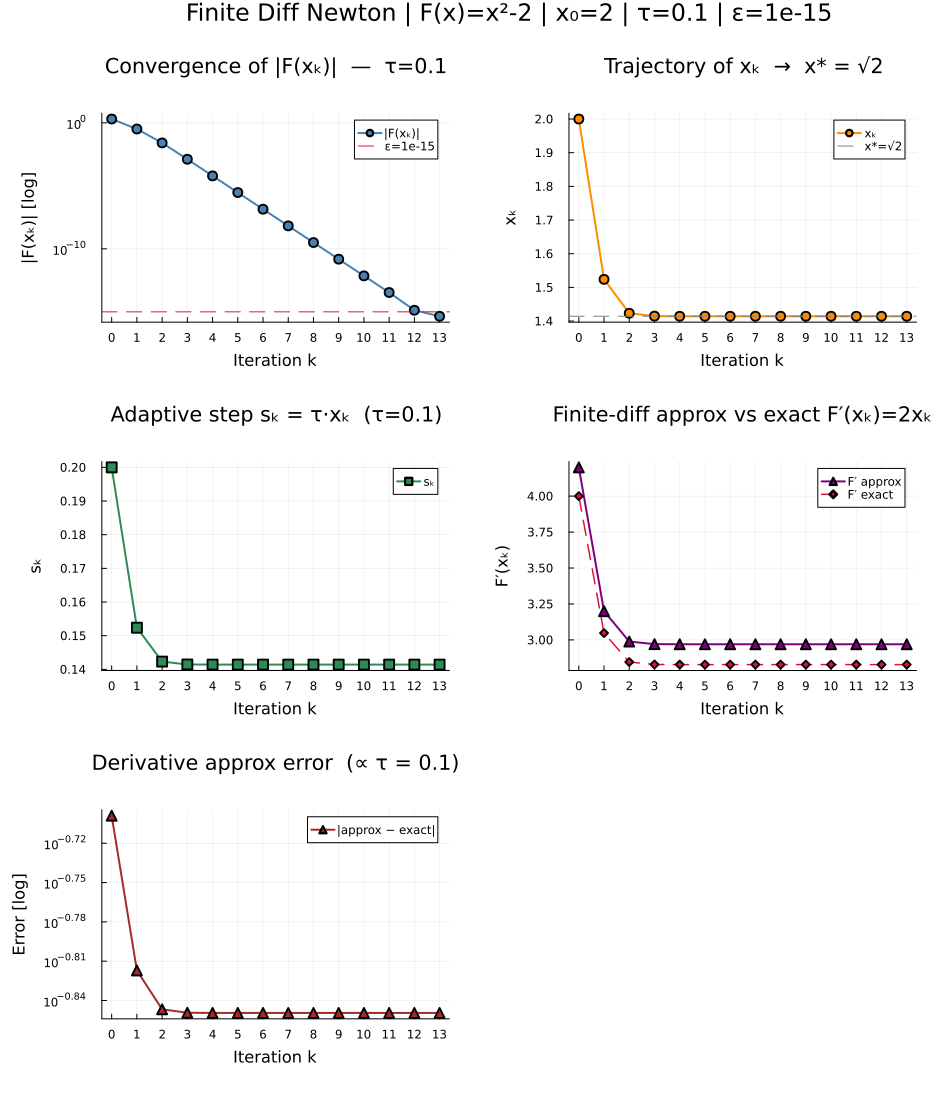

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Finite Difference Newton's Method: one variable
#
# Key idea: replaces the exact derivative F′(xₖ) with the finite difference
#
#         F(xₖ + s) − F(xₖ)
#   F′ ≈  ─────────────────
#                 s
#
# where the step s adapts to the magnitude of xₖ:
#   |xₖ| ≥ 1  →  s = τ·xₖ    (relative step)
#   |xₖ| < 1  →  s = τ        (absolute step)
#
# Update rule (line 17):
#   xₖ₊₁ := xₖ − s·F(xₖ) / [F(xₖ+s) − F(xₖ)]
#
# Input:  F, x₀, τ, ε
# Output: x* ≈ solution of F(x) = 0
# ─────────────────────────────────────────────────────────────────────────────

function newton_findiff(F, x0::Float64;
                        τ::Float64  = 1e-7,
                        ε::Float64  = 1e-15,
                        maxiter::Int = 1000)

    println("─"^86)
    @printf("  %-5s  %-22s  %-22s  %-18s  %-14s\n",
            "k", "x_k", "F(x_k)", "s_k", "F'_approx")
    println("─"^86)

    k  = 0                              # line 11 – Initialization
    xk = x0

    history = NamedTuple[]

    function step_size(xk)             # lines 13–16
        abs(xk) ≥ 1 ? τ * xk : τ
    end

    function record_and_print(k, xk, s)
        Fxk    = F(xk)
        Fxks   = F(xk + s)
        dapprox = (Fxks - Fxk) / s
        push!(history, (k=k, x=xk, Fx=Fxk, s=s, dapprox=dapprox))
        @printf("  %-5d  %-22.15f  %-22.15f  %-18.6e  %-14.10f\n",
                k, xk, Fxk, s, dapprox)
    end

    # initial row
    record_and_print(k, xk, step_size(xk))

    status = :running
    while true                          # line 12 – Repeat

        s    = step_size(xk)            # lines 13–16
        Fxk  = F(xk)
        Fxks = F(xk + s)
        denom = Fxks - Fxk

        if abs(denom) < 1e-30
            println("  ⚠  F(xₖ+s) − F(xₖ) ≈ 0 at k=$k — stopping.")
            status = :singular; break
        end

        xk1 = xk - s * Fxk / denom    # line 17 – finite difference Newton step
        k  += 1                         # line 18 – k := k + 1
        xk  = xk1

        if !isfinite(xk)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        record_and_print(k, xk, step_size(xk))

        if abs(F(xk)) ≤ ε              # line 19 – Until |F(xₖ)| ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println("─"^86)
    sym = status == :converged ? "✔  Converged" : "✘  Did not converge"
    @printf("\n  %s:  x* = %.15f\n", sym, xk)
    @printf("  |F(x*)| = %.6e   (iterations: %d,  status: %s)\n\n",
            abs(F(xk)), k, status)

    return xk, history                  # line 20 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example:  F(x) = x² − 2 = 0   →   x* = √2
#           x₀ = 2,   τ = 1e-7,   ε = 1e-15
# ─────────────────────────────────────────────────────────────────────────────

F_ex  = x -> x^2 - 2.0
dF_ex = x -> 2.0 * x     # exact derivative — used only for comparison

println("\n▶  Finite Difference Newton — Algorithm 8.1")
println("   F(x) = x² − 2 = 0")
println("   x₀ = 2,   τ = 1e-7,   ε = 1e-15\n")

xstar, hist = newton_findiff(F_ex, 2.0; τ = 1e-7, ε = 1e-15)

@printf("  √2 (reference) = %.15f\n", sqrt(2.0))
@printf("  error          = %.6e\n\n", abs(xstar - sqrt(2.0)))

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks      = [h.k        for h in hist]
xtk     = 0:maximum(ks)
xks     = [h.x        for h in hist]
fks     = [abs(h.Fx)  for h in hist]
sks     = [abs(h.s)   for h in hist]
dapprox = [h.dapprox  for h in hist]
dexact  = [dF_ex(h.x) for h in hist]
derr    = [abs(a - b) for (a,b) in zip(dapprox, dexact)]

p1 = plot(ks, max.(fks, 1e-35);
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:steelblue, label="|F(xₖ)|",
    ylabel="|F(xₖ)| [log]", xlabel="Iteration k", xticks=xtk,
    title="Convergence of |F(xₖ)|", grid=true)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

p2 = plot(ks, xks;
    seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:darkorange, label="xₖ",
    ylabel="xₖ", xlabel="Iteration k", xticks=xtk,
    title="Trajectory of xₖ  →  x* = √2", grid=true)
hline!(p2, [sqrt(2.0)]; color=:grey, linestyle=:dash, label="x*=√2")

p3 = plot(ks, sks;
    seriestype=:line, marker=:square, markersize=6,
    linewidth=2, color=:seagreen, label="sₖ",
    ylabel="sₖ", xlabel="Iteration k", xticks=xtk,
    title="Adaptive step sₖ  (τ·xₖ or τ)", grid=true)

p4 = plot(ks, dapprox;
    seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:purple, label="F′ approx",
    ylabel="F′(xₖ)", xlabel="Iteration k", xticks=xtk,
    title="Finite-diff approx vs exact F′(xₖ) = 2xₖ", grid=true)
plot!(p4, ks, dexact;
    seriestype=:line, marker=:diamond, markersize=5,
    linewidth=1.5, linestyle=:dash, color=:crimson, label="F′ exact")

p5 = plot(ks, max.(derr, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:brown, label="|approx − exact|",
    ylabel="Error [log]", xlabel="Iteration k", xticks=xtk,
    title="Derivative approximation error", grid=true)

plot(p1, p2, p3, p4, p5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Finite Diff Newton | F(x)=x²-2 | x₀=2 | τ=1e-7 | ε=1e-15",
    margin=6Plots.mm)


# ─────────────────────────────────────────────────────────────────────────────
# Same example with τ = 0.1  (larger finite-difference step)
# Expected: converges but needs more iterations due to coarser derivative approx
# ─────────────────────────────────────────────────────────────────────────────

println("\n▶  Finite Difference Newton — τ = 0.1")
println("   F(x) = x² − 2 = 0")
println("   x₀ = 2,   τ = 0.1,   ε = 1e-15\n")

xstar2, hist2 = newton_findiff(F_ex, 2.0; τ = 0.1, ε = 1e-15)

@printf("  √2 (reference) = %.15f\n", sqrt(2.0))
@printf("  error          = %.6e\n\n", abs(xstar2 - sqrt(2.0)))

ks2      = [h.k        for h in hist2]
xtk2     = 0:maximum(ks2)
xks2     = [h.x        for h in hist2]
fks2     = [abs(h.Fx)  for h in hist2]
sks2     = [abs(h.s)   for h in hist2]
dapprox2 = [h.dapprox  for h in hist2]
dexact2  = [dF_ex(h.x) for h in hist2]
derr2    = [abs(a - b) for (a,b) in zip(dapprox2, dexact2)]

q1 = plot(ks2, max.(fks2, 1e-35);
    yscale=:log10, seriestype=:line, marker=:circle, markersize=5,
    linewidth=2, color=:steelblue, label="|F(xₖ)|",
    ylabel="|F(xₖ)| [log]", xlabel="Iteration k", xticks=xtk2,
    title="Convergence of |F(xₖ)|  —  τ=0.1", grid=true)
hline!(q1, [1e-15]; color=:crimson, linestyle=:dash, label="ε=1e-15")

q2 = plot(ks2, xks2;
    seriestype=:line, marker=:circle, markersize=5,
    linewidth=2, color=:darkorange, label="xₖ",
    ylabel="xₖ", xlabel="Iteration k", xticks=xtk2,
    title="Trajectory of xₖ  →  x* = √2", grid=true)
hline!(q2, [sqrt(2.0)]; color=:grey, linestyle=:dash, label="x*=√2")

q3 = plot(ks2, sks2;
    seriestype=:line, marker=:square, markersize=5,
    linewidth=2, color=:seagreen, label="sₖ",
    ylabel="sₖ", xlabel="Iteration k", xticks=xtk2,
    title="Adaptive step sₖ = τ·xₖ  (τ=0.1)", grid=true)

q4 = plot(ks2, dapprox2;
    seriestype=:line, marker=:utriangle, markersize=5,
    linewidth=2, color=:purple, label="F′ approx",
    ylabel="F′(xₖ)", xlabel="Iteration k", xticks=xtk2,
    title="Finite-diff approx vs exact F′(xₖ)=2xₖ", grid=true)
plot!(q4, ks2, dexact2;
    seriestype=:line, marker=:diamond, markersize=4,
    linewidth=1.5, linestyle=:dash, color=:crimson, label="F′ exact")

q5 = plot(ks2, max.(derr2, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=5,
    linewidth=2, color=:brown, label="|approx − exact|",
    ylabel="Error [log]", xlabel="Iteration k", xticks=xtk2,
    title="Derivative approx error  (∝ τ = 0.1)", grid=true)

plot(q1, q2, q3, q4, q5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Finite Diff Newton | F(x)=x²-2 | x₀=2 | τ=0.1 | ε=1e-15",
    margin=6Plots.mm)



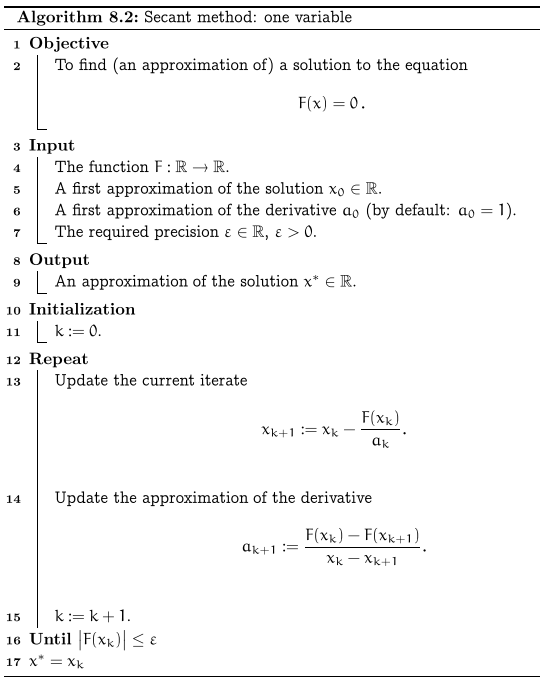

Example: $F(x)=x^2-2$, with $x_0=2$ and $a_0=1$


▶  Secant Method — Algorithm 8.2
   F(x) = x² − 2 = 0
   x₀ = 2,   a₀ = 1,   ε = 1e-15

────────────────────────────────────────────────────────────────────────────────
  k      x_k                     F(x_k)                  a_k                   
────────────────────────────────────────────────────────────────────────────────
  0      2.000000000000000       2.000000000000000       1.000000000000000     
  1      0.000000000000000       -2.000000000000000      2.000000000000000     
  2      1.000000000000000       -1.000000000000000      1.000000000000000     
  3      2.000000000000000       2.000000000000000       3.000000000000000     
  4      1.333333333333333       -0.222222222222222      3.333333333333333     
  5      1.400000000000000       -0.040000000000000      2.733333333333335     
  6      1.414634146341463       0.001189767995241       2.814634146341470     
  7      1.414211438474870       -0.000006007286839      2.828845584816847     
  8      1.414213562057320   

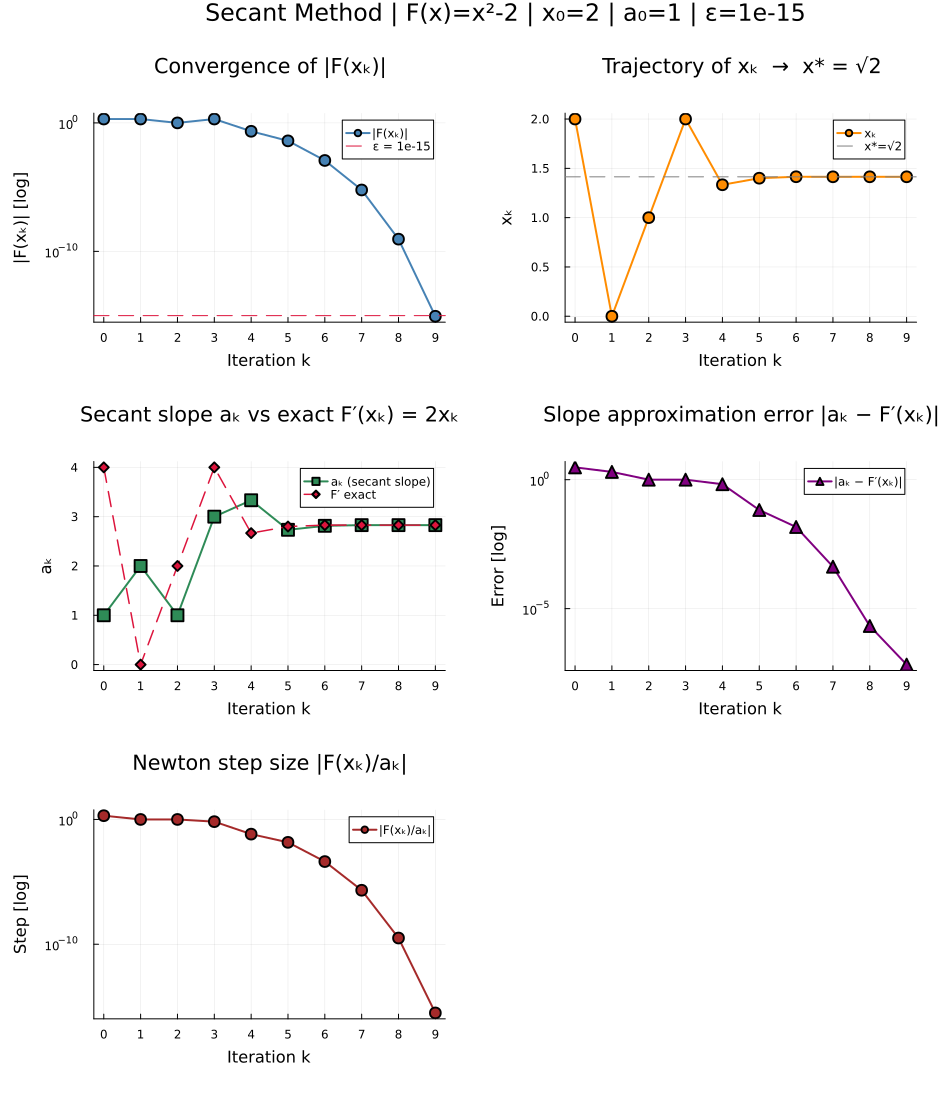

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Secant Method: one variable
#
# Key idea: no derivative F′ is required. Instead, the slope aₖ is updated
# each iteration using the secant (finite-difference between two iterates):
#
#         F(xₖ) − F(xₖ₊₁)
#   aₖ₊₁ = ─────────────────
#              xₖ − xₖ₊₁
#
# This is equivalent to drawing a line through (xₖ, F(xₖ)) and (xₖ₊₁, F(xₖ₊₁))
# and finding where it crosses zero.
#
# Input:  F, x₀, a₀ (initial slope approx, default = 1), ε
# Output: x* ≈ solution of F(x) = 0
# ─────────────────────────────────────────────────────────────────────────────

function secant(F, x0::Float64, a0::Float64 = 1.0;
                ε::Float64   = 1e-15,
                maxiter::Int = 1000)

    println("─"^80)
    @printf("  %-5s  %-22s  %-22s  %-22s\n", "k", "x_k", "F(x_k)", "a_k")
    println("─"^80)

    k  = 0                              # line 11 – Initialization
    xk = x0
    ak = a0

    history = NamedTuple[]
    push!(history, (k=k, x=xk, Fx=F(xk), a=ak))
    @printf("  %-5d  %-22.15f  %-22.15f  %-22.15f\n", k, xk, F(xk), ak)

    status = :running
    while true                          # line 12 – Repeat

        if abs(ak) < 1e-30
            println("  ⚠  aₖ ≈ 0 at k=$k — stopping.")
            status = :singular; break
        end

        Fxk = F(xk)
        xk1 = xk - Fxk / ak            # line 13 – update iterate

        if !isfinite(xk1)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        Fxk1 = F(xk1)

        denom = xk - xk1
        if abs(denom) < 1e-30
            println("  ⚠  xₖ − xₖ₊₁ ≈ 0 at k=$k — stopping.")
            status = :stagnation; break
        end

        ak1 = (Fxk - Fxk1) / denom     # line 14 – update slope (secant)

        k  += 1                         # line 15 – k := k + 1
        xk  = xk1
        ak  = ak1

        push!(history, (k=k, x=xk, Fx=F(xk), a=ak))
        @printf("  %-5d  %-22.15f  %-22.15f  %-22.15f\n", k, xk, F(xk), ak)

        if abs(F(xk)) ≤ ε              # line 16 – Until |F(xₖ)| ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println("─"^80)
    sym = status == :converged ? "✔  Converged" : "✘  Did not converge"
    @printf("\n  %s:  x* = %.15f\n", sym, xk)
    @printf("  |F(x*)| = %.6e   (iterations: %d,  status: %s)\n\n",
            abs(F(xk)), k, status)

    return xk, history                  # line 17 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example:  F(x) = x² − 2 = 0   →   x* = √2
#           x₀ = 2,   a₀ = 1,   ε = 1e-15
# ─────────────────────────────────────────────────────────────────────────────

F_ex  = x -> x^2 - 2.0
dF_ex = x -> 2.0 * x     # exact derivative — comparison only

println("\n▶  Secant Method — Algorithm 8.2")
println("   F(x) = x² − 2 = 0")
println("   x₀ = 2,   a₀ = 1,   ε = 1e-15\n")

xstar, hist = secant(F_ex, 2.0, 1.0; ε = 1e-15)

@printf("  √2 (reference) = %.15f\n", sqrt(2.0))
@printf("  error          = %.6e\n\n", abs(xstar - sqrt(2.0)))

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h.k       for h in hist]
xtk  = 0:maximum(ks)
xks  = [h.x       for h in hist]
fks  = [abs(h.Fx) for h in hist]
aks  = [h.a       for h in hist]
dex  = [dF_ex(h.x) for h in hist]
derr = [abs(a - b) for (a,b) in zip(aks, dex)]
stps = [abs(h.Fx / h.a) for h in hist if abs(h.a) > 1e-30]
ks_s = [h.k for h in hist if abs(h.a) > 1e-30]

p1 = plot(ks, max.(fks, 1e-35);
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:steelblue, label="|F(xₖ)|",
    ylabel="|F(xₖ)| [log]", xlabel="Iteration k", xticks=xtk,
    title="Convergence of |F(xₖ)|", grid=true)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

p2 = plot(ks, xks;
    seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:darkorange, label="xₖ",
    ylabel="xₖ", xlabel="Iteration k", xticks=xtk,
    title="Trajectory of xₖ  →  x* = √2", grid=true)
hline!(p2, [sqrt(2.0)]; color=:grey, linestyle=:dash, label="x*=√2")

p3 = plot(ks, aks;
    seriestype=:line, marker=:square, markersize=6,
    linewidth=2, color=:seagreen, label="aₖ (secant slope)",
    ylabel="aₖ", xlabel="Iteration k", xticks=xtk,
    title="Secant slope aₖ vs exact F′(xₖ) = 2xₖ", grid=true)
plot!(p3, ks, dex;
    seriestype=:line, marker=:diamond, markersize=5,
    linewidth=1.5, linestyle=:dash, color=:crimson, label="F′ exact")

p4 = plot(ks, max.(derr, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:purple, label="|aₖ − F′(xₖ)|",
    ylabel="Error [log]", xlabel="Iteration k", xticks=xtk,
    title="Slope approximation error |aₖ − F′(xₖ)|", grid=true)

p5 = plot(ks_s, max.(stps, 1e-35);
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:brown, label="|F(xₖ)/aₖ|",
    ylabel="Step [log]", xlabel="Iteration k", xticks=xtk,
    title="Newton step size |F(xₖ)/aₖ|", grid=true)

plot(p1, p2, p3, p4, p5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Secant Method | F(x)=x²-2 | x₀=2 | a₀=1 | ε=1e-15",
    margin=6Plots.mm)


### Algorithm 8.3: finite difference Newton's method: $n$ variables

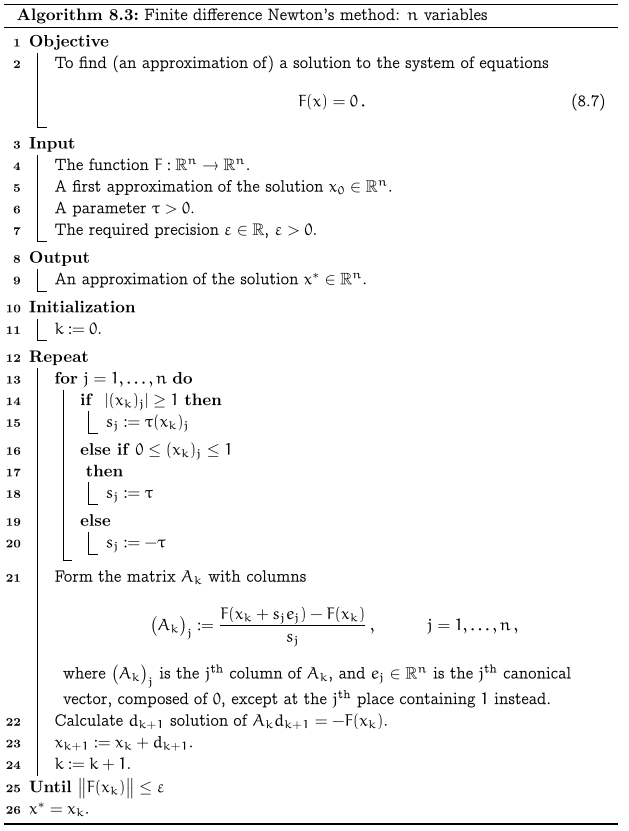

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=10^{-7}$


▶  Finite Difference Newton n variables — Algorithm 8.3
   F(x) = [(x₁+1)² + x₂² − 2,  eˣ¹ + x₂³ − 2]ᵀ
   x₀ = (1, 1)ᵀ,   τ = 1e-7,   ε = 1e-15

────────────────────────────────────────────────────────────────────────────────────
  k      x1_k                    x2_k                    ‖F(xₖ)‖                 det(Aₖ)        
────────────────────────────────────────────────────────────────────────────────────
  0      1.000000000000000       1.000000000000000       3.457238e+00            6.56343732     
  1      0.152359228410735       1.195281579252624       1.154709e+00            7.09424298     
  2      -0.010837685000800      1.036111188598883       1.140426e-01            4.32146590     
  3      -0.000889667832882      1.001535322500209       3.942346e-03            4.01179454     
  4      -0.000001370169295      1.000002938923894       8.080614e-06            4.00002420     
  5      -0.000000000005688      1.000000000011159       2.986392e-11            4.00000031     
  6  

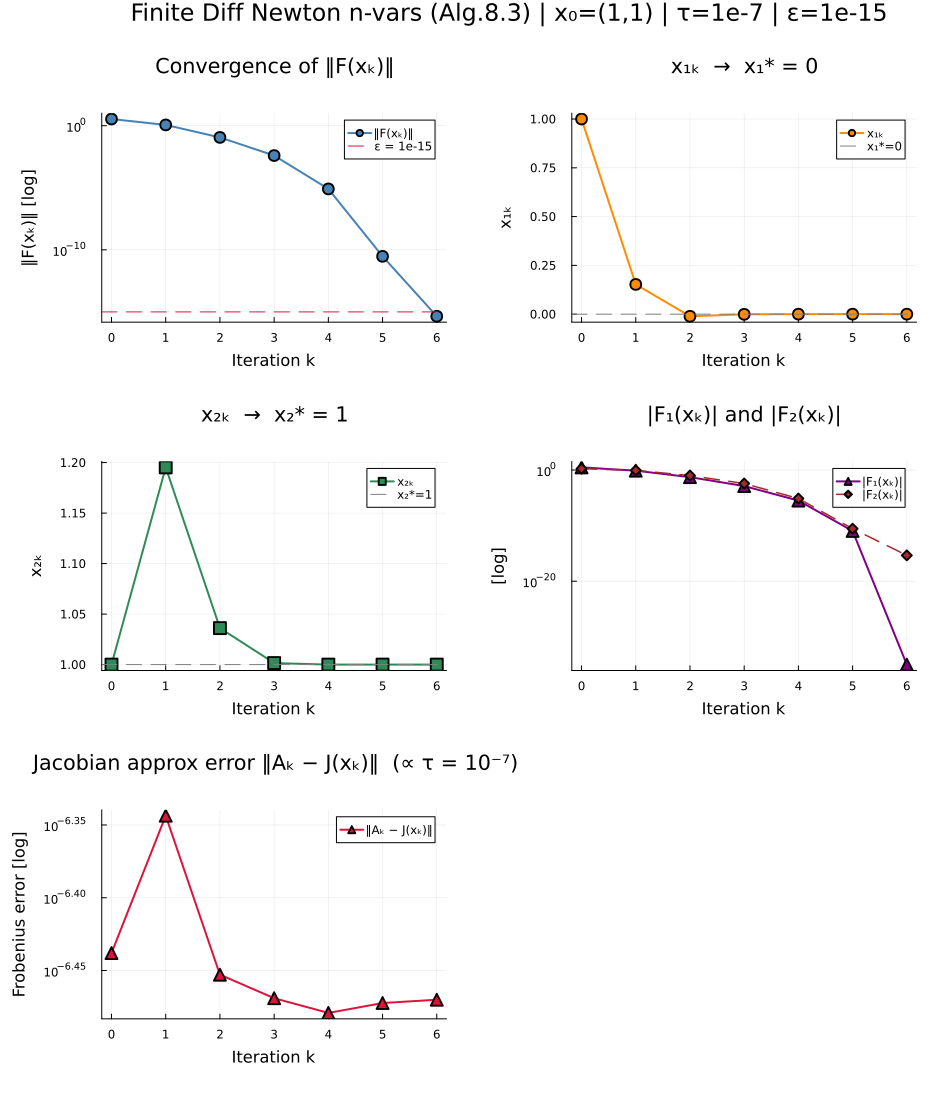

In [7]:

# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Finite Difference Newton's Method: n variables
#
# Key idea: replaces the exact Jacobian J(xₖ) with a finite-difference
# approximation Aₖ built column by column:
#
#   (Aₖ)ⱼ = [F(xₖ + sⱼeⱼ) − F(xₖ)] / sⱼ       j = 1,…,n
#
# where eⱼ is the j-th canonical vector and sⱼ adapts to (xₖ)ⱼ:
#   |(xₖ)ⱼ| ≥ 1         →  sⱼ =  τ·(xₖ)ⱼ     (relative, lines 14-15)
#   0 ≤ (xₖ)ⱼ ≤ 1       →  sⱼ =  τ            (absolute, lines 16-18)
#   (xₖ)ⱼ < 0  & |·|<1  →  sⱼ = −τ            (negative, lines 19-20)
#
# Then solve Aₖ·dₖ₊₁ = −F(xₖ) and update xₖ₊₁ = xₖ + dₖ₊₁
# ─────────────────────────────────────────────────────────────────────────────

"""Adaptive step size for component j (lines 14–20)."""
function choose_step(xkj::Float64, τ::Float64) :: Float64
    if abs(xkj) ≥ 1
        return τ * xkj          # line 15 – relative step
    elseif 0.0 ≤ xkj ≤ 1.0
        return τ                 # line 18 – absolute positive step
    else
        return -τ                # line 20 – absolute negative step
    end
end

"""
Build the finite-difference Jacobian approximation Aₖ (line 21).
Returns (Aₖ, F(xₖ)).
"""
function fd_jacobian(F, xk::Vector{Float64}, τ::Float64)
    n  = length(xk)
    Fk = F(xk)
    Ak = zeros(Float64, n, n)
    for j in 1:n
        sj       = choose_step(xk[j], τ)
        ej       = zeros(Float64, n); ej[j] = 1.0
        Ak[:, j] = (F(xk + sj*ej) - Fk) / sj   # j-th column
    end
    return Ak, Fk
end

"""
Algorithm 8.3 – Finite Difference Newton: n variables.

Input:
  F        – function ℝⁿ → ℝⁿ
  x0       – initial approximation
  τ        – finite-difference parameter
  ε        – required precision
  maxiter  – safety cap

Output: x*, iteration history
"""
function newton_findiff_n(F, x0::Vector{Float64};
                          τ::Float64   = 1e-7,
                          ε::Float64   = 1e-15,
                          maxiter::Int = 1000)
    n   = length(x0)
    sep = "─" ^ (14 + 22*n + 26)

    println(sep)
    hdr = @sprintf("  %-5s", "k")
    for i in 1:n; hdr *= @sprintf("  %-22s", "x$(i)_k"); end
    hdr *= @sprintf("  %-22s  %-15s", "‖F(xₖ)‖", "det(Aₖ)")
    println(hdr); println(sep)

    function print_row(k, xk, nrm, detA)
        row = @sprintf("  %-5d", k)
        for v in xk; row *= @sprintf("  %-22.15f", v); end
        row *= @sprintf("  %-22.6e  %-15.8f", nrm, detA)
        println(row)
    end

    k  = 0                              # line 11 – Initialization
    xk = copy(x0)
    Ak, Fk = fd_jacobian(F, xk, τ)

    history = NamedTuple[]
    push!(history, (k=k, x=copy(xk), Fx=copy(Fk),
                    nrm=norm(Fk), detA=det(Ak), Ak=copy(Ak)))
    print_row(k, xk, norm(Fk), det(Ak))

    status = :running
    while true                          # line 12 – Repeat

        Ak, Fk = fd_jacobian(F, xk, τ) # line 13-21 – build Aₖ

        if abs(det(Ak)) < 1e-14
            println("  ⚠  Aₖ near-singular at k=$k — stopping.")
            status = :singular; break
        end

        dk1 = Ak \ (-Fk)               # line 22 – solve Aₖ·d = −F(xₖ)
        xk  = xk + dk1                  # line 23 – xₖ₊₁ := xₖ + dₖ₊₁
        k  += 1                         # line 24 – k := k + 1

        if any(!isfinite, xk)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        Ak2, Fk2 = fd_jacobian(F, xk, τ)
        nrm = norm(Fk2)
        push!(history, (k=k, x=copy(xk), Fx=copy(Fk2),
                        nrm=nrm, detA=det(Ak2), Ak=copy(Ak2)))
        print_row(k, xk, nrm, det(Ak2))

        if nrm ≤ ε                      # line 25 – Until ‖F(xₖ)‖ ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println(sep)
    sym = status == :converged ? "✔  Converged" : "✘  Did not converge"
    print("\n  $sym:  x* = (")
    print(join([@sprintf("%.15f", v) for v in xk], ",  "))
    println(")")
    @printf("  ‖F(x*)‖ = %.6e   (iterations: %d,  status: %s)\n\n",
            norm(F(xk)), k, status)

    return xk, history                  # line 26 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example
#
#   F(x) = [ (x₁+1)² + x₂² − 2  ]     x* = (0, 1)ᵀ
#           [ eˣ¹   + x₂³  − 2  ]
#
#   Exact Jacobian (for error comparison only):
#   J(x) = [ 2(x₁+1)   2x₂   ]
#           [ eˣ¹       3x₂²  ]
#
#   x₀ = (1, 1)ᵀ,   τ = 1e-7,   ε = 1e-15
# ─────────────────────────────────────────────────────────────────────────────

F_ex  = x -> [ (x[1]+1)^2 + x[2]^2 - 2.0,
                exp(x[1])  + x[2]^3 - 2.0 ]

J_ex  = x -> [ 2*(x[1]+1)   2*x[2]   ;
                exp(x[1])    3*x[2]^2  ]   # exact Jacobian — comparison only

println("\n▶  Finite Difference Newton n variables — Algorithm 8.3")
println("   F(x) = [(x₁+1)² + x₂² − 2,  eˣ¹ + x₂³ − 2]ᵀ")
println("   x₀ = (1, 1)ᵀ,   τ = 1e-7,   ε = 1e-15\n")

xstar, hist = newton_findiff_n(F_ex, [1.0, 1.0]; τ = 1e-7, ε = 1e-15)

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h.k        for h in hist]
xtk  = 0:maximum(ks)
x1s  = [h.x[1]    for h in hist]
x2s  = [h.x[2]    for h in hist]
f1s  = [abs(h.Fx[1]) for h in hist]
f2s  = [abs(h.Fx[2]) for h in hist]
nrms = [max(h.nrm, 1e-35) for h in hist]

# Frobenius error ‖Aₖ − J(xₖ)‖_F
jerr = [norm(h.Ak - J_ex(h.x), 2) for h in hist]

p1 = plot(ks, nrms;
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:steelblue, label="‖F(xₖ)‖",
    ylabel="‖F(xₖ)‖ [log]", xlabel="Iteration k", xticks=xtk,
    title="Convergence of ‖F(xₖ)‖", grid=true)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

p2 = plot(ks, x1s;
    seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:darkorange, label="x₁ₖ",
    ylabel="x₁ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₁ₖ  →  x₁* = 0", grid=true)
hline!(p2, [0.0]; color=:grey, linestyle=:dash, label="x₁*=0")

p3 = plot(ks, x2s;
    seriestype=:line, marker=:square, markersize=6,
    linewidth=2, color=:seagreen, label="x₂ₖ",
    ylabel="x₂ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₂ₖ  →  x₂* = 1", grid=true)
hline!(p3, [1.0]; color=:grey, linestyle=:dash, label="x₂*=1")

p4 = plot(ks, max.(f1s, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:purple, label="|F₁(xₖ)|",
    ylabel="[log]", xlabel="Iteration k", xticks=xtk,
    title="|F₁(xₖ)| and |F₂(xₖ)|", grid=true)
plot!(p4, ks, max.(f2s, 1e-35);
    seriestype=:line, marker=:diamond, markersize=5,
    linewidth=1.5, linestyle=:dash, color=:brown, label="|F₂(xₖ)|")

p5 = plot(ks, max.(jerr, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:crimson, label="‖Aₖ − J(xₖ)‖",
    ylabel="Frobenius error [log]", xlabel="Iteration k", xticks=xtk,
    title="Jacobian approx error ‖Aₖ − J(xₖ)‖  (∝ τ = 10⁻⁷)", grid=true)

plot(p1, p2, p3, p4, p5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Finite Diff Newton n-vars (Alg.8.3) | x₀=(1,1) | τ=1e-7 | ε=1e-15",
    margin=6Plots.mm)

Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=0.1$


▶  Finite Difference Newton n variables — Algorithm 8.3
   F(x) = [(x₁+1)² + x₂² − 2,  eˣ¹ + x₂³ − 2]ᵀ
   x₀ = (1, 1)ᵀ,   τ = 1e-7,   ε = 1e-15

────────────────────────────────────────────────────────────────────────────────────
  k      x1_k                    x2_k                    ‖F(xₖ)‖                 det(Aₖ)        
────────────────────────────────────────────────────────────────────────────────────
  0      1.000000000000000       1.000000000000000       3.457238e+00            6.56343732     
  1      0.152359228410735       1.195281579252624       1.154709e+00            7.09424298     
  2      -0.010837685000800      1.036111188598883       1.140426e-01            4.32146590     
  3      -0.000889667832882      1.001535322500209       3.942346e-03            4.01179454     
  4      -0.000001370169295      1.000002938923894       8.080614e-06            4.00002420     
  5      -0.000000000005688      1.000000000011159       2.986392e-11            4.00000031     
  6  

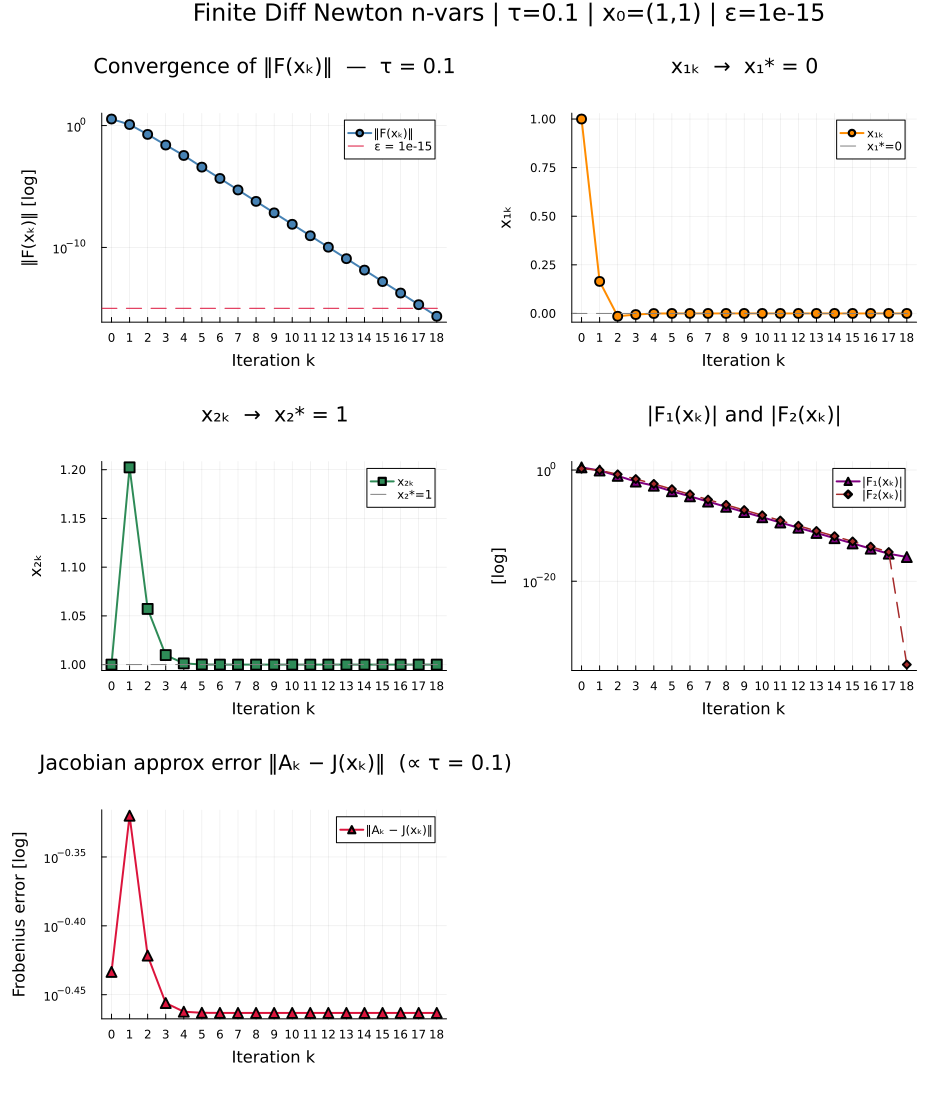

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Finite Difference Newton's Method: n variables
#
# Key idea: replaces the exact Jacobian J(xₖ) with a finite-difference
# approximation Aₖ built column by column:
#
#   (Aₖ)ⱼ = [F(xₖ + sⱼeⱼ) − F(xₖ)] / sⱼ       j = 1,…,n
#
# where eⱼ is the j-th canonical vector and sⱼ adapts to (xₖ)ⱼ:
#   |(xₖ)ⱼ| ≥ 1         →  sⱼ =  τ·(xₖ)ⱼ     (relative, lines 14-15)
#   0 ≤ (xₖ)ⱼ ≤ 1       →  sⱼ =  τ            (absolute, lines 16-18)
#   (xₖ)ⱼ < 0  & |·|<1  →  sⱼ = −τ            (negative, lines 19-20)
#
# Then solve Aₖ·dₖ₊₁ = −F(xₖ) and update xₖ₊₁ = xₖ + dₖ₊₁
# ─────────────────────────────────────────────────────────────────────────────

"""Adaptive step size for component j (lines 14–20)."""
function choose_step(xkj::Float64, τ::Float64) :: Float64
    if abs(xkj) ≥ 1
        return τ * xkj          # line 15 – relative step
    elseif 0.0 ≤ xkj ≤ 1.0
        return τ                 # line 18 – absolute positive step
    else
        return -τ                # line 20 – absolute negative step
    end
end

"""
Build the finite-difference Jacobian approximation Aₖ (line 21).
Returns (Aₖ, F(xₖ)).
"""
function fd_jacobian(F, xk::Vector{Float64}, τ::Float64)
    n  = length(xk)
    Fk = F(xk)
    Ak = zeros(Float64, n, n)
    for j in 1:n
        sj       = choose_step(xk[j], τ)
        ej       = zeros(Float64, n); ej[j] = 1.0
        Ak[:, j] = (F(xk + sj*ej) - Fk) / sj   # j-th column
    end
    return Ak, Fk
end

"""
Algorithm 8.3 – Finite Difference Newton: n variables.

Input:
  F        – function ℝⁿ → ℝⁿ
  x0       – initial approximation
  τ        – finite-difference parameter
  ε        – required precision
  maxiter  – safety cap

Output: x*, iteration history
"""
function newton_findiff_n(F, x0::Vector{Float64};
                          τ::Float64   = 1e-7,
                          ε::Float64   = 1e-15,
                          maxiter::Int = 1000)
    n   = length(x0)
    sep = "─" ^ (14 + 22*n + 26)

    println(sep)
    hdr = @sprintf("  %-5s", "k")
    for i in 1:n; hdr *= @sprintf("  %-22s", "x$(i)_k"); end
    hdr *= @sprintf("  %-22s  %-15s", "‖F(xₖ)‖", "det(Aₖ)")
    println(hdr); println(sep)

    function print_row(k, xk, nrm, detA)
        row = @sprintf("  %-5d", k)
        for v in xk; row *= @sprintf("  %-22.15f", v); end
        row *= @sprintf("  %-22.6e  %-15.8f", nrm, detA)
        println(row)
    end

    k  = 0                              # line 11 – Initialization
    xk = copy(x0)
    Ak, Fk = fd_jacobian(F, xk, τ)

    history = NamedTuple[]
    push!(history, (k=k, x=copy(xk), Fx=copy(Fk),
                    nrm=norm(Fk), detA=det(Ak), Ak=copy(Ak)))
    print_row(k, xk, norm(Fk), det(Ak))

    status = :running
    while true                          # line 12 – Repeat

        Ak, Fk = fd_jacobian(F, xk, τ) # line 13-21 – build Aₖ

        if abs(det(Ak)) < 1e-14
            println("  ⚠  Aₖ near-singular at k=$k — stopping.")
            status = :singular; break
        end

        dk1 = Ak \ (-Fk)               # line 22 – solve Aₖ·d = −F(xₖ)
        xk  = xk + dk1                  # line 23 – xₖ₊₁ := xₖ + dₖ₊₁
        k  += 1                         # line 24 – k := k + 1

        if any(!isfinite, xk)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        Ak2, Fk2 = fd_jacobian(F, xk, τ)
        nrm = norm(Fk2)
        push!(history, (k=k, x=copy(xk), Fx=copy(Fk2),
                        nrm=nrm, detA=det(Ak2), Ak=copy(Ak2)))
        print_row(k, xk, nrm, det(Ak2))

        if nrm ≤ ε                      # line 25 – Until ‖F(xₖ)‖ ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println(sep)
    sym = status == :converged ? "✔  Converged" : "✘  Did not converge"
    print("\n  $sym:  x* = (")
    print(join([@sprintf("%.15f", v) for v in xk], ",  "))
    println(")")
    @printf("  ‖F(x*)‖ = %.6e   (iterations: %d,  status: %s)\n\n",
            norm(F(xk)), k, status)

    return xk, history                  # line 26 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example
#
#   F(x) = [ (x₁+1)² + x₂² − 2  ]     x* = (0, 1)ᵀ
#           [ eˣ¹   + x₂³  − 2  ]
#
#   Exact Jacobian (for error comparison only):
#   J(x) = [ 2(x₁+1)   2x₂   ]
#           [ eˣ¹       3x₂²  ]
#
#   x₀ = (1, 1)ᵀ,   τ = 1e-7,   ε = 1e-15
# ─────────────────────────────────────────────────────────────────────────────

F_ex  = x -> [ (x[1]+1)^2 + x[2]^2 - 2.0,
                exp(x[1])  + x[2]^3 - 2.0 ]

J_ex  = x -> [ 2*(x[1]+1)   2*x[2]   ;
                exp(x[1])    3*x[2]^2  ]   # exact Jacobian — comparison only

println("\n▶  Finite Difference Newton n variables — Algorithm 8.3")
println("   F(x) = [(x₁+1)² + x₂² − 2,  eˣ¹ + x₂³ − 2]ᵀ")
println("   x₀ = (1, 1)ᵀ,   τ = 1e-7,   ε = 1e-15\n")

xstar, hist = newton_findiff_n(F_ex, [1.0, 1.0]; τ = 1e-7, ε = 1e-15)

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h.k        for h in hist]
xtk  = 0:maximum(ks)
x1s  = [h.x[1]    for h in hist]
x2s  = [h.x[2]    for h in hist]
f1s  = [abs(h.Fx[1]) for h in hist]
f2s  = [abs(h.Fx[2]) for h in hist]
nrms = [max(h.nrm, 1e-35) for h in hist]

# Frobenius error ‖Aₖ − J(xₖ)‖_F
jerr = [norm(h.Ak - J_ex(h.x), 2) for h in hist]

p1 = plot(ks, nrms;
    yscale=:log10, seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:steelblue, label="‖F(xₖ)‖",
    ylabel="‖F(xₖ)‖ [log]", xlabel="Iteration k", xticks=xtk,
    title="Convergence of ‖F(xₖ)‖", grid=true)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

p2 = plot(ks, x1s;
    seriestype=:line, marker=:circle, markersize=6,
    linewidth=2, color=:darkorange, label="x₁ₖ",
    ylabel="x₁ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₁ₖ  →  x₁* = 0", grid=true)
hline!(p2, [0.0]; color=:grey, linestyle=:dash, label="x₁*=0")

p3 = plot(ks, x2s;
    seriestype=:line, marker=:square, markersize=6,
    linewidth=2, color=:seagreen, label="x₂ₖ",
    ylabel="x₂ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₂ₖ  →  x₂* = 1", grid=true)
hline!(p3, [1.0]; color=:grey, linestyle=:dash, label="x₂*=1")

p4 = plot(ks, max.(f1s, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:purple, label="|F₁(xₖ)|",
    ylabel="[log]", xlabel="Iteration k", xticks=xtk,
    title="|F₁(xₖ)| and |F₂(xₖ)|", grid=true)
plot!(p4, ks, max.(f2s, 1e-35);
    seriestype=:line, marker=:diamond, markersize=5,
    linewidth=1.5, linestyle=:dash, color=:brown, label="|F₂(xₖ)|")

p5 = plot(ks, max.(jerr, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=6,
    linewidth=2, color=:crimson, label="‖Aₖ − J(xₖ)‖",
    ylabel="Frobenius error [log]", xlabel="Iteration k", xticks=xtk,
    title="Jacobian approx error ‖Aₖ − J(xₖ)‖  (∝ τ = 10⁻⁷)", grid=true)

plot(p1, p2, p3, p4, p5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Finite Diff Newton n-vars (Alg.8.3) | x₀=(1,1) | τ=1e-7 | ε=1e-15",
    margin=6Plots.mm)


# ─────────────────────────────────────────────────────────────────────────────
# Same example with τ = 0.1  (larger finite-difference step)
# Expected: converges but needs more iterations — coarser Jacobian approx
# ─────────────────────────────────────────────────────────────────────────────
println("\n▶  Finite Difference Newton n variables — τ = 0.1")
println("   F(x) = [(x₁+1)² + x₂² − 2,  eˣ¹ + x₂³ − 2]ᵀ")
println("   x₀ = (1, 1)ᵀ,   τ = 0.1,   ε = 1e-15\n")

xstar2, hist2 = newton_findiff_n(F_ex, [1.0, 1.0]; τ = 0.1, ε = 1e-15)

ks2   = [h.k        for h in hist2]
xtk2  = 0:maximum(ks2)
x1s2  = [h.x[1]    for h in hist2]
x2s2  = [h.x[2]    for h in hist2]
f1s2  = [abs(h.Fx[1]) for h in hist2]
f2s2  = [abs(h.Fx[2]) for h in hist2]
nrms2 = [max(h.nrm, 1e-35) for h in hist2]
jerr2 = [norm(h.Ak - J_ex(h.x), 2) for h in hist2]

q1 = plot(ks2, nrms2;
    yscale=:log10, seriestype=:line, marker=:circle, markersize=5,
    linewidth=2, color=:steelblue, label="‖F(xₖ)‖",
    ylabel="‖F(xₖ)‖ [log]", xlabel="Iteration k", xticks=xtk2,
    title="Convergence of ‖F(xₖ)‖  —  τ = 0.1", grid=true)
hline!(q1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

q2 = plot(ks2, x1s2;
    seriestype=:line, marker=:circle, markersize=5,
    linewidth=2, color=:darkorange, label="x₁ₖ",
    ylabel="x₁ₖ", xlabel="Iteration k", xticks=xtk2,
    title="x₁ₖ  →  x₁* = 0", grid=true)
hline!(q2, [0.0]; color=:grey, linestyle=:dash, label="x₁*=0")

q3 = plot(ks2, x2s2;
    seriestype=:line, marker=:square, markersize=5,
    linewidth=2, color=:seagreen, label="x₂ₖ",
    ylabel="x₂ₖ", xlabel="Iteration k", xticks=xtk2,
    title="x₂ₖ  →  x₂* = 1", grid=true)
hline!(q3, [1.0]; color=:grey, linestyle=:dash, label="x₂*=1")

q4 = plot(ks2, max.(f1s2, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=5,
    linewidth=2, color=:purple, label="|F₁(xₖ)|",
    ylabel="[log]", xlabel="Iteration k", xticks=xtk2,
    title="|F₁(xₖ)| and |F₂(xₖ)|", grid=true)
plot!(q4, ks2, max.(f2s2, 1e-35);
    seriestype=:line, marker=:diamond, markersize=4,
    linewidth=1.5, linestyle=:dash, color=:brown, label="|F₂(xₖ)|")

q5 = plot(ks2, max.(jerr2, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=5,
    linewidth=2, color=:crimson, label="‖Aₖ − J(xₖ)‖",
    ylabel="Frobenius error [log]", xlabel="Iteration k", xticks=xtk2,
    title="Jacobian approx error ‖Aₖ − J(xₖ)‖  (∝ τ = 0.1)", grid=true)

plot(q1, q2, q3, q4, q5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Finite Diff Newton n-vars | τ=0.1 | x₀=(1,1) | ε=1e-15",
    margin=6Plots.mm)


### Algorithm 8.4: secant method: $n$ variables

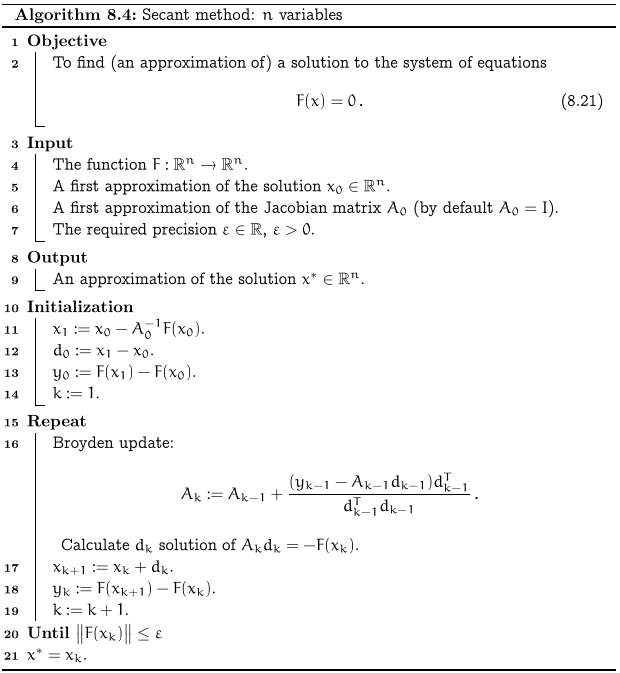

Example 7.11: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$, $x_0=\left(\begin{array}{c} 1 \\ 1 \end{array}\right)$



▶  Broyden Secant Method — Algorithm 8.4
   F(x) = [(x₁+1)² + x₂² − 2,  eˣ¹ + x₂³ − 2]ᵀ
   x₀ = (1, 1)ᵀ,   A₀ = I,   ε = 1e-15

────────────────────────────────────────────────────────────────────────────────────
  k      x1_k                    x2_k                    ‖F(xₖ)‖                 det(Aₖ)        
────────────────────────────────────────────────────────────────────────────────────
  0      1.000000000000000       1.000000000000000       3.457238e+00            1.00000000     
  1      -2.000000000000000      -0.718281828459045      2.287062e+00            1.00000000     
  2      -1.664500259833028      0.830921595643864       1.511178e+00            1.44283633     
  3      -0.242562564049364      2.037712135069413       7.741565e+00            0.74605836     
  4      -1.241555821941724      0.771291329025235       1.838980e+00            4.90136864     
  5      -0.580521668428695      0.422211781428677       2.138259e+00            5.35024442     
  6      -3.2619320912

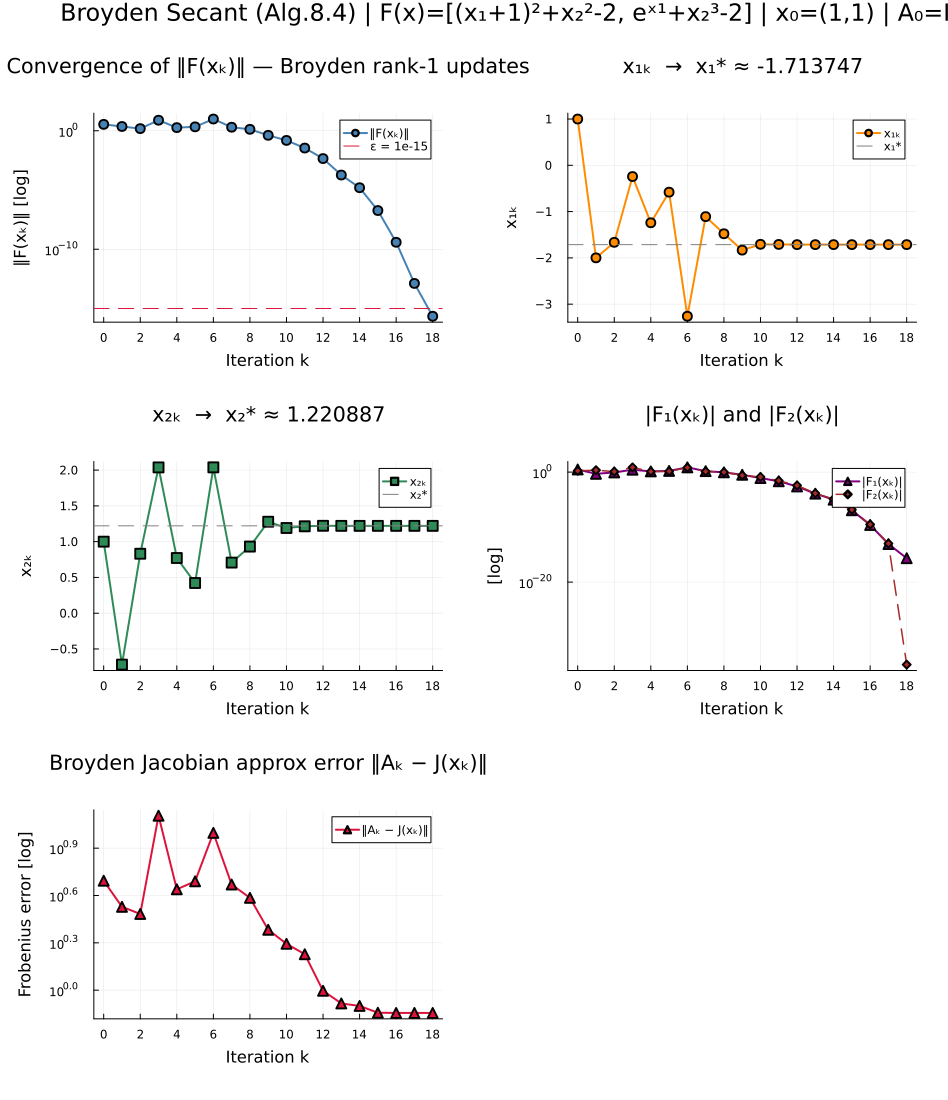

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Algorithm – Secant Method (Broyden): n variables
#
# Key idea: no Jacobian needed. Aₖ is updated each step by a rank-1
# correction (Broyden's update) that is consistent with the secant condition:
#
#   Aₖ · dₖ₋₁ = yₖ₋₁     where  dₖ₋₁ = xₖ − xₖ₋₁,  yₖ₋₁ = F(xₖ) − F(xₖ₋₁)
#
# Broyden rank-1 update (line 16):
#
#         (yₖ₋₁ − Aₖ₋₁ dₖ₋₁) dₖ₋₁ᵀ
#   Aₖ := Aₖ₋₁ + ────────────────────
#                    dₖ₋₁ᵀ dₖ₋₁
#
# Initialization (lines 11-14):
#   x₁ := x₀ − A₀⁻¹ F(x₀)
#   d₀ := x₁ − x₀
#   y₀ := F(x₁) − F(x₀)
#   k  := 1
# ─────────────────────────────────────────────────────────────────────────────

function broyden(F, x0::Vector{Float64},
                 A0::Matrix{Float64} = Matrix{Float64}(I, length(x0), length(x0));
                 ε::Float64   = 1e-15,
                 maxiter::Int = 500)

    n   = length(x0)
    sep = "─" ^ (14 + 22*n + 26)

    println(sep)
    hdr = @sprintf("  %-5s", "k")
    for i in 1:n; hdr *= @sprintf("  %-22s", "x$(i)_k"); end
    hdr *= @sprintf("  %-22s  %-15s", "‖F(xₖ)‖", "det(Aₖ)")
    println(hdr); println(sep)

    function print_row(k, xk, nrm, detA)
        row = @sprintf("  %-5d", k)
        for v in xk; row *= @sprintf("  %-22.15f", v); end
        row *= @sprintf("  %-22.6e  %-15.8f", nrm, detA)
        println(row)
    end

    # ── Initialization (lines 11-14) ─────────────────────────────────────────
    Fx0 = F(x0)
    x1  = x0 - A0 \ Fx0                 # line 11
    d0  = x1 - x0                       # line 12
    y0  = F(x1) - Fx0                   # line 13
    k   = 1                             # line 14

    xk = copy(x1)
    Ak = copy(A0)
    dk = copy(d0)
    yk = copy(y0)

    history = NamedTuple[]
    push!(history, (k=0, x=copy(x0), Fx=copy(Fx0), nrm=norm(Fx0), detA=det(A0), Ak=copy(A0)))
    push!(history, (k=1, x=copy(xk), Fx=F(xk),     nrm=norm(F(xk)), detA=det(Ak), Ak=copy(Ak)))

    print_row(0, x0, norm(Fx0), det(A0))
    print_row(1, xk, norm(F(xk)), det(Ak))

    status = :running
    while true                           # line 15 – Repeat

        dkm1 = copy(dk)
        ykm1 = copy(yk)

        # Broyden rank-1 update (line 16)
        denom = dot(dkm1, dkm1)
        if abs(denom) < 1e-30
            println("  ⚠  dᵀd ≈ 0 at k=$k — stopping.")
            status = :singular; break
        end
        Ak = Ak + ((ykm1 - Ak * dkm1) * dkm1') / denom

        if abs(det(Ak)) < 1e-14
            println("  ⚠  Aₖ singular at k=$k — stopping.")
            status = :singular; break
        end

        dk  = Ak \ (-F(xk))             # solve Aₖ dₖ = −F(xₖ)
        xk1 = xk + dk                   # line 17 – xₖ₊₁ := xₖ + dₖ
        yk  = F(xk1) - F(xk)            # line 18 – yₖ := F(xₖ₊₁) − F(xₖ)
        k  += 1                         # line 19 – k := k + 1
        xk  = xk1

        if any(!isfinite, xk)
            println("  ⚠  xₖ diverged at k=$k — stopping.")
            status = :diverged; break
        end

        nrm = norm(F(xk))
        push!(history, (k=k, x=copy(xk), Fx=F(xk), nrm=nrm, detA=det(Ak), Ak=copy(Ak)))
        print_row(k, xk, nrm, det(Ak))

        if nrm ≤ ε                      # line 20 – Until ‖F(xₖ)‖ ≤ ε
            status = :converged; break
        end
        if k ≥ maxiter
            println("  ⚠  Maximum iterations ($maxiter) reached.")
            status = :maxiter; break
        end
    end

    println(sep)
    sym = status == :converged ? "✔  Converged" : "✘  Did not converge"
    print("\n  $sym:  x* = (")
    print(join([@sprintf("%.15f", v) for v in xk], ",  "))
    println(")")
    @printf("  ‖F(x*)‖ = %.6e   (iterations: %d,  status: %s)\n\n",
            norm(F(xk)), k, status)

    return xk, history                  # line 21 – x* = xₖ
end

# ─────────────────────────────────────────────────────────────────────────────
# Example (7.11):
#   F(x) = [ (x₁+1)² + x₂² − 2  ]
#           [ eˣ¹   + x₂³  − 2  ]
#
#   x₀ = (1, 1)ᵀ,   A₀ = I,   ε = 1e-15
#
#   Exact Jacobian (comparison only):
#   J(x) = [ 2(x₁+1)   2x₂  ]
#           [ eˣ¹       3x₂² ]
# ─────────────────────────────────────────────────────────────────────────────

F_ex = x -> [ (x[1]+1)^2 + x[2]^2 - 2.0,
               exp(x[1])  + x[2]^3 - 2.0 ]

J_ex = x -> [ 2*(x[1]+1)   2*x[2]   ;
               exp(x[1])    3*x[2]^2  ]

println("\n▶  Broyden Secant Method — Algorithm 8.4")
println("   F(x) = [(x₁+1)² + x₂² − 2,  eˣ¹ + x₂³ − 2]ᵀ")
println("   x₀ = (1, 1)ᵀ,   A₀ = I,   ε = 1e-15\n")

xstar, hist = broyden(F_ex, [1.0, 1.0]; ε = 1e-15)

# ─────────────────────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────────────────────
ks   = [h.k        for h in hist]
xtk  = 0:2:maximum(ks)               # every-2 ticks (18 iterations)
x1s  = [h.x[1]    for h in hist]
x2s  = [h.x[2]    for h in hist]
f1s  = [abs(h.Fx[1]) for h in hist]
f2s  = [abs(h.Fx[2]) for h in hist]
nrms = [max(h.nrm, 1e-35) for h in hist]
jerr = [norm(h.Ak - J_ex(h.x), 2)  for h in hist]

p1 = plot(ks, nrms;
    yscale=:log10, seriestype=:line, marker=:circle, markersize=5,
    linewidth=2, color=:steelblue, label="‖F(xₖ)‖",
    ylabel="‖F(xₖ)‖ [log]", xlabel="Iteration k", xticks=xtk,
    title="Convergence of ‖F(xₖ)‖ — Broyden rank-1 updates", grid=true)
hline!(p1, [1e-15]; color=:crimson, linestyle=:dash, label="ε = 1e-15")

p2 = plot(ks, x1s;
    seriestype=:line, marker=:circle, markersize=5,
    linewidth=2, color=:darkorange, label="x₁ₖ",
    ylabel="x₁ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₁ₖ  →  x₁* ≈ $(round(xstar[1], digits=6))", grid=true)
hline!(p2, [xstar[1]]; color=:grey, linestyle=:dash, label="x₁*")

p3 = plot(ks, x2s;
    seriestype=:line, marker=:square, markersize=5,
    linewidth=2, color=:seagreen, label="x₂ₖ",
    ylabel="x₂ₖ", xlabel="Iteration k", xticks=xtk,
    title="x₂ₖ  →  x₂* ≈ $(round(xstar[2], digits=6))", grid=true)
hline!(p3, [xstar[2]]; color=:grey, linestyle=:dash, label="x₂*")

p4 = plot(ks, max.(f1s, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=5,
    linewidth=2, color=:purple, label="|F₁(xₖ)|",
    ylabel="[log]", xlabel="Iteration k", xticks=xtk,
    title="|F₁(xₖ)| and |F₂(xₖ)|", grid=true)
plot!(p4, ks, max.(f2s, 1e-35);
    seriestype=:line, marker=:diamond, markersize=4,
    linewidth=1.5, linestyle=:dash, color=:brown, label="|F₂(xₖ)|")

p5 = plot(ks, max.(jerr, 1e-35);
    yscale=:log10, seriestype=:line, marker=:utriangle, markersize=5,
    linewidth=2, color=:crimson, label="‖Aₖ − J(xₖ)‖",
    ylabel="Frobenius error [log]", xlabel="Iteration k", xticks=xtk,
    title="Broyden Jacobian approx error ‖Aₖ − J(xₖ)‖", grid=true)

plot(p1, p2, p3, p4, p5;
    layout=(3, 2), size=(950, 1100),
    plot_title="Broyden Secant (Alg.8.4) | F(x)=[(x₁+1)²+x₂²-2, eˣ¹+x₂³-2] | x₀=(1,1) | A₀=I",
    margin=6Plots.mm)
